In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy import sparse
import joblib

In [ ]:
X_train = sparse.load_npz("X_train_processed.npz")
X_test = sparse.load_npz("X_test_processed.npz")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13060, 402)
X_test: (3124, 402)
y_train: (13060,)
y_test: (3124,)


In [ ]:
linear_model = joblib.load(
    "linear_regression_model.pkl"
)

decision_tree_model = joblib.load(
    "decision_tree_model.pkl"
)

random_forest_model = joblib.load(
    "random_forest_model.pkl"
)

xgb_model = joblib.load(
    "xgboost_regression_model.pkl"
)

models = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

print("Models loaded successfully.")

Models loaded successfully.


In [ ]:
train_predictions = {}
test_predictions = {}

for name, model in models.items():

    train_predictions[name] = model.predict(X_train)
    test_predictions[name] = model.predict(X_test)

print("Train and test predictions generated.")

Train and test predictions generated.


In [ ]:
results = []

for name in models:

    mae = mean_absolute_error(
        y_test,
        test_predictions[name]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions[name]
        )
    )

    r2 = r2_score(
        y_test,
        test_predictions[name]
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R²
0,Linear Regression,5.864040,8.033634,0.721740
1,Decision Tree,1.889059,3.231902,0.954966
2,Random Forest,1.730608,2.879764,0.964245
3,XGBoost,1.833650,2.840469,0.965214


In [ ]:
results_df[
    ["MAE", "RMSE", "R²"]
] = results_df[
    ["MAE", "RMSE", "R²"]
].round(3)

results_df

,Model,MAE,RMSE,R²
0,Linear Regression,5.864,8.034,0.722
1,Decision Tree,1.889,3.232,0.955
2,Random Forest,1.731,2.880,0.964
3,XGBoost,1.834,2.840,0.965


In [ ]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Best model based on RMSE:")
print(best_model_name)

Best model based on RMSE:
XGBoost


In [ ]:
best_result = results_df[
    results_df["Model"] == best_model_name
]

print(best_result.to_string(index=False))

  Model   MAE  RMSE    R²
XGBoost 1.834  2.84 0.965


In [ ]:
overfitting_results = []

for name in models:

    train_r2 = r2_score(
        y_train,
        train_predictions[name]
    )

    test_r2 = r2_score(
        y_test,
        test_predictions[name]
    )

    train_mae = mean_absolute_error(
        y_train,
        train_predictions[name]
    )

    test_mae = mean_absolute_error(
        y_test,
        test_predictions[name]
    )

    overfitting_results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Difference": train_r2 - test_r2
    })

overfitting_df = pd.DataFrame(
    overfitting_results
)

overfitting_df.round(4)

,Model,Train MAE,Test MAE,Train R²,Test R²,R² Difference
0,Linear Regression,5.7084,5.8640,0.7394,0.7217,0.0177
1,Decision Tree,1.1185,1.8891,0.9850,0.9550,0.0301
2,Random Forest,1.1593,1.7306,0.9859,0.9642,0.0216
3,XGBoost,1.3362,1.8337,0.9841,0.9652,0.0189


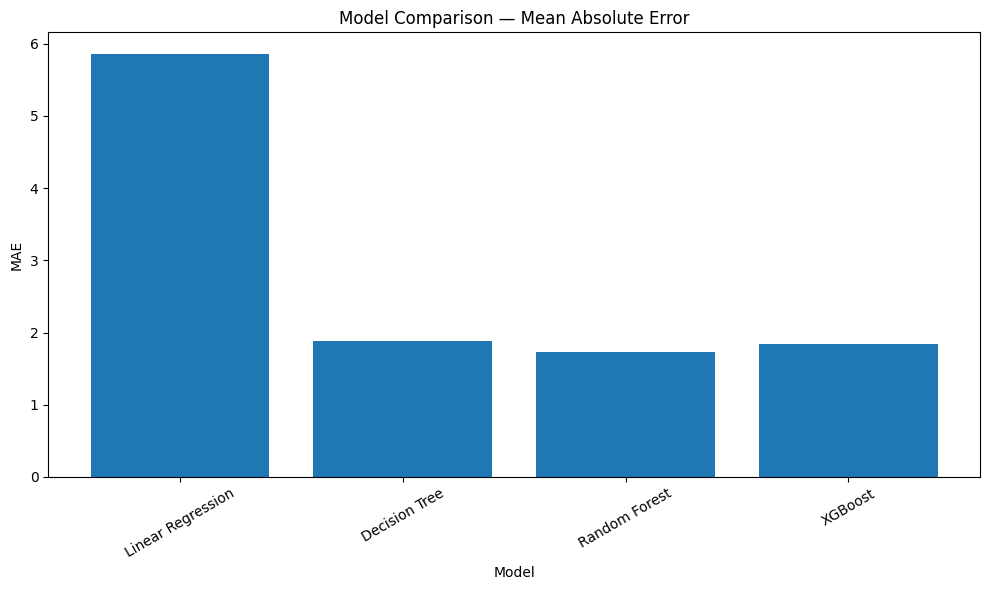

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison — Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

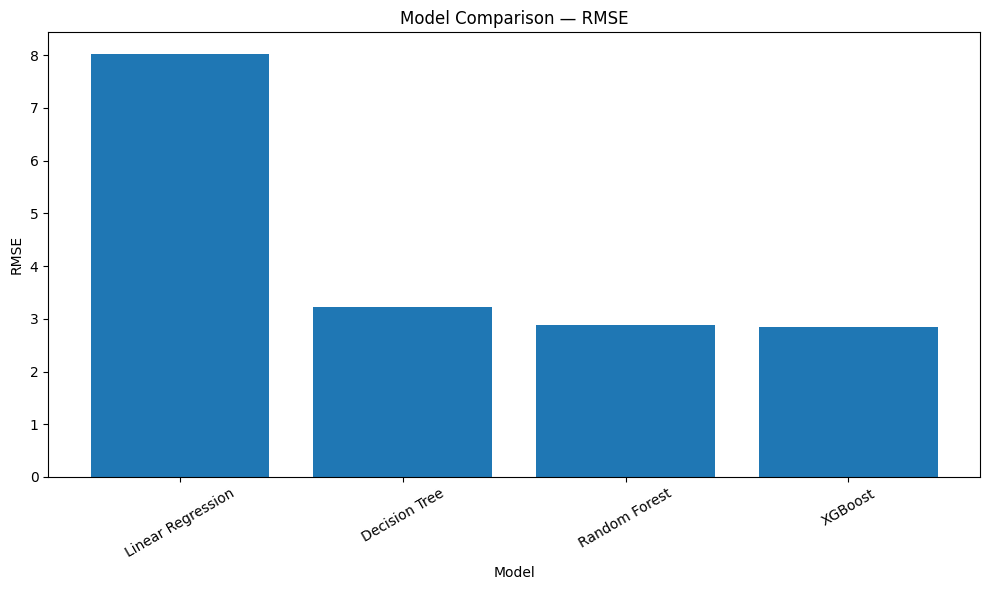

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

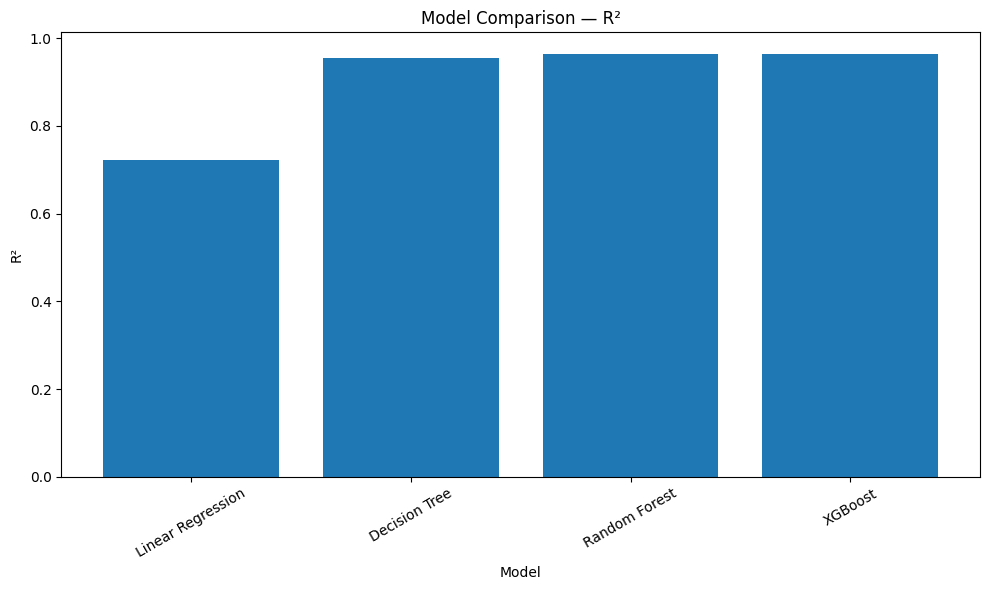

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R²"]
)

plt.title("Model Comparison — R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

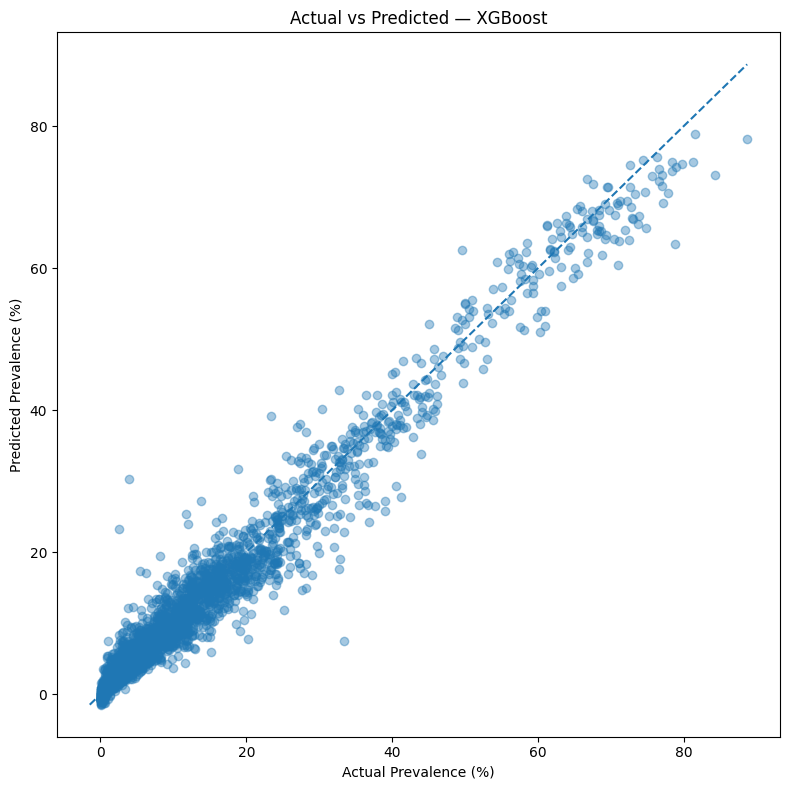

In [ ]:
best_predictions = test_predictions[best_model_name]

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted — {best_model_name}"
)

plt.xlabel("Actual Prevalence (%)")
plt.ylabel("Predicted Prevalence (%)")

plt.tight_layout()
plt.show()

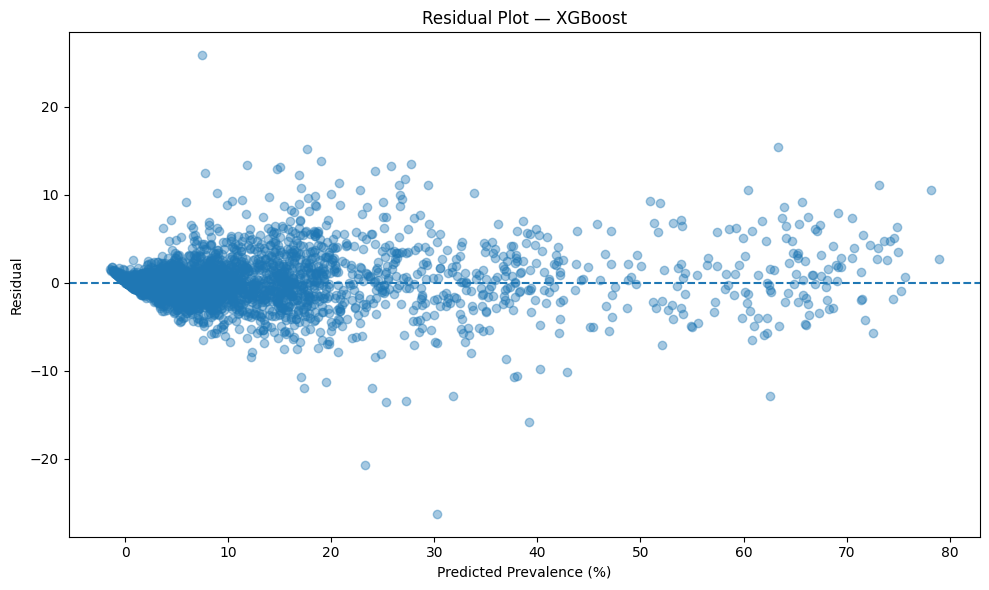

In [ ]:
residuals = (
    y_test.values -
    best_predictions
)

plt.figure(figsize=(10, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.xlabel("Predicted Prevalence (%)")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

In [ ]:
for name, prediction in test_predictions.items():

    negative = (prediction < 0).sum()
    above_100 = (prediction > 100).sum()

    print(f"\n{name}")
    print("Negative predictions:", negative)
    print("Predictions above 100%:", above_100)


Linear Regression
Negative predictions: 530
Predictions above 100%: 0

Decision Tree
Negative predictions: 0
Predictions above 100%: 0

Random Forest
Negative predictions: 0
Predictions above 100%: 0

XGBoost
Negative predictions: 123
Predictions above 100%: 0


In [ ]:
final_predictions = pd.DataFrame({
    "Actual Prevalence": y_test.values,
    "Predicted Prevalence": best_predictions,
    "Residual": residuals
})

final_predictions.head(20)

,Actual Prevalence,Predicted Prevalence,Residual
0,17.573222,13.227513,4.345708
1,11.982743,10.041887,1.940855
2,22.420901,20.064196,2.356705
3,25.951557,25.483906,0.467651
4,25.789474,25.483906,0.305568
5,4.411765,5.334914,-0.923149
6,3.150242,5.070120,-1.919878
7,9.509202,10.810621,-1.301419
8,5.810928,5.940954,-0.130026
9,2.321347,1.984012,0.337336


In [ ]:
results_df.to_csv(
    "phase5_model_evaluation.csv",
    index=False
)

overfitting_df.to_csv(
    "phase5_overfitting_analysis.csv",
    index=False
)

final_predictions.to_csv(
    "phase5_final_predictions.csv",
    index=False
)

print("Phase 5 results saved successfully.")

Phase 5 results saved successfully.
